<center><h1> Three-Eloop </h1></center>

In [1]:
from MCA_lib1_2 import *
import pennylane as qml
import warnings
warnings.filterwarnings('ignore')

## Variables Input

In [2]:
# Number of desired symbols
num_ext_edges=5
num_int_edges=5
num_edges =num_ext_edges+num_int_edges
num_no_reverse_clauses = 21

num_propagator_edge = 2
needs_extra_qubit = False

name_diagram = '5E20'

num_shots = 300000

cut = 40

## Logical Variables

In [3]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [4]:
######################## Loops - 3 propagators ######################

c[0] = And(S[0],S[6], Sp[5])
          
c[1] = And(S[1], S[7], Sp[6]) #21

c[2] = And(S[2], S[8], Sp[7]) #22

c[3] = And(S[3],S[9], Sp[8]) #23

c[4] = And(S[4],S[5], Sp[9]) #24
       
######################## Loops - 4 propagators ######################

c[5] = And(S[0],S[1], S[7], Sp[5])

c[6] = And(S[1],S[2], S[8], Sp[6]) #25

c[7] = And(S[2],S[3], S[9], Sp[7]) #26 

c[8] = And(S[3],S[4], S[5], Sp[8]) #27

c[9] = And(S[0],S[4], S[6], Sp[9])



######################## Loops - 5 propagators ######################

c[10] = And(S[0],S[1], S[2],S[8], Sp[5])

c[11] = And(S[1],S[2], S[3],S[9], Sp[6]) #28

c[12] = And(S[2],S[3], S[4],S[5], Sp[7]) #29

c[13] = And(S[0],S[3],S[4], S[6], Sp[8])

c[14] = And(S[0],S[1],S[4], S[7], Sp[9])


######################## Loops - 6 propagators ######################

c[15] = And(S[0],S[1], S[2],S[3],S[9], Sp[5])

c[16] = And(S[1],S[2], S[3],S[4],S[5], Sp[6]) #30

c[17] = And(S[0],S[2],S[3], S[4],S[6], Sp[7])

c[18] = And(S[0],S[1],S[3],S[4], S[7], Sp[8])

c[19] = And(S[0],S[1],S[2],S[4], S[8], Sp[9])


######################## exterior Loop  ######################

c[20] = And(S[0], S[1], S[2], S[3], S[4])

######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [5]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)
Graph_matrix_clauses

array([[0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0.,
        0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0.,
        0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1.],
       [0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,
        0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1.],
       [1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1.],
       [0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
        1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.],
       [0., 1

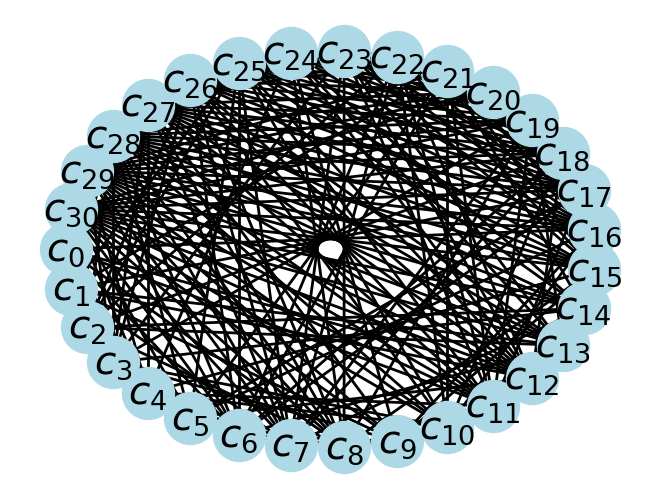

In [6]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = '5e20_clauses')


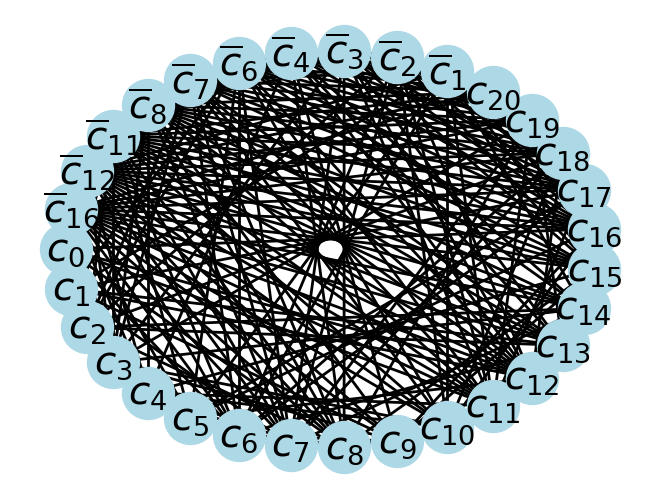

In [7]:
graph_clausesR = graph_clauses_Rev(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_ClausesRev')

[[-6, -8, 14, 11, 17],
 [-1, -2, 10, 16],
 [-3, -4, 12, 18],
 [-7, 19, 8, 15],
 [-11, 2, 1, 13],
 [-12, 3, 9, 6],
 [4, 5, -16, 7],
 [0],
 [20]]

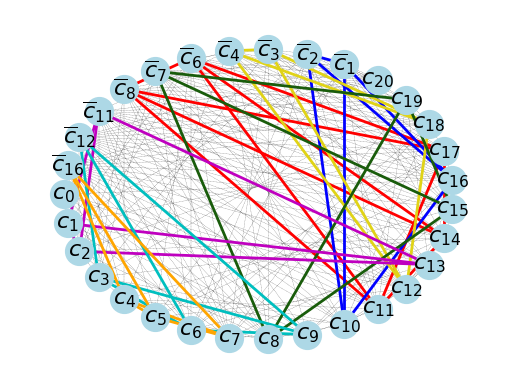

In [8]:
graph_clausesC = graph_clauses_C(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_Clauses_cliques')
graph_clausesC[1]

In [9]:
clauses_combination = Graph_condition_combination(graph_clauses,clauses,S,c)
clauses_combination

([[25, 27, 14, 11, 17],
  [21, 22, 10, 16],
  [23, 24, 12, 18],
  [26, 19, 8, 15],
  [28, 2, 1, 13],
  [29, 3, 9, 6],
  [4, 5, 30, 7],
  [0],
  [20]],
 [[-6, -8, 14, 11, 17],
  [-1, -2, 10, 16],
  [-3, -4, 12, 18],
  [-7, 19, 8, 15],
  [-11, 2, 1, 13],
  [-12, 3, 9, 6],
  [4, 5, -16, 7],
  [0],
  [20]])

## Depth

In [10]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

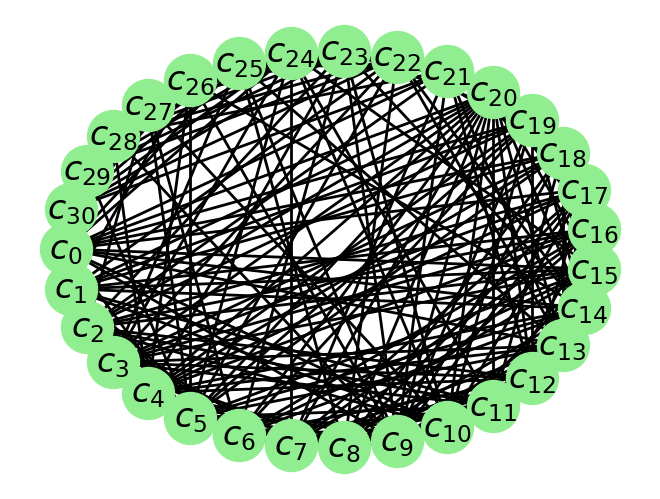

In [11]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

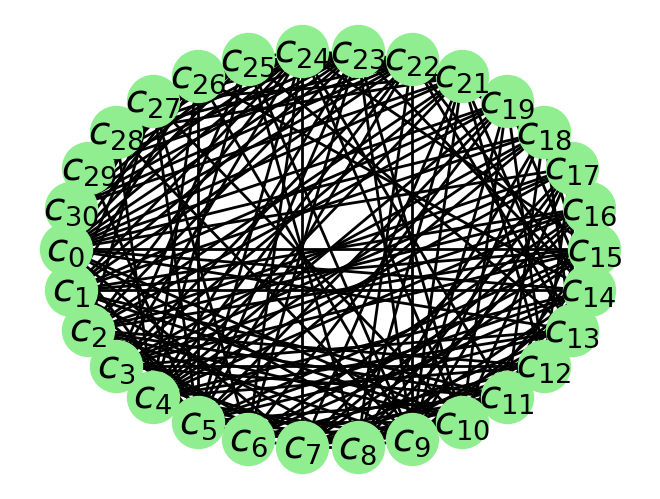

In [12]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

[[20],
 [0, 5, 9, 14, 10, 19, -3],
 [3, 8, 13, -1, 17, 12, 7],
 [-6, -2, -7, -11, -12, -16],
 [1, 6, 11, -4, 15],
 [16, 4, 2],
 [18],
 [-8]]

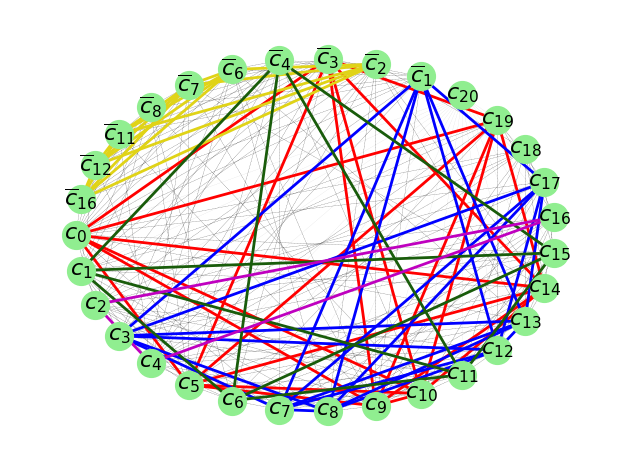

In [13]:
graph_depthf=graph_depthC(S,c,clauses,num_ext_edges,Set_edges, draw = True,name_graph = '3e9')
graph_depthf[1]

In [14]:
depth_combination = Graph_condition_combination(graph_depth,clauses,S,c)
depth_combination

([[20, 3, 7, 8, 12, 16, 11],
  [0, 5, 10, 9, 19, 14],
  [26, 28, 29, 30, 25, 22],
  [23, 2, 27, 6],
  [1, 18, 15],
  [17, 13, 4],
  [24],
  [21]],
 [[20, 3, 7, 8, 12, 16, 11],
  [0, 5, 10, 9, 19, 14],
  [-7, -11, -12, -16, -6, -2],
  [-3, 2, -8, 6],
  [1, 18, 15],
  [17, 13, 4],
  [-4],
  [-1]])

In [15]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges,S,c)
depth_combination3
#[[3], [0, 4], [1, 5], [2]]


([[20],
  [0, 5, 9, 14, 10, 19, 23],
  [3, 8, 13, 21, 17, 12, 7],
  [25, 22, 26, 28, 29, 30],
  [1, 6, 11, 24, 15],
  [16, 4, 2],
  [18],
  [27]],
 [[20],
  [0, 5, 9, 14, 10, 19, -3],
  [3, 8, 13, -1, 17, 12, 7],
  [-6, -2, -7, -11, -12, -16],
  [1, 6, 11, -4, 15],
  [16, 4, 2],
  [18],
  [-8]])

<left><h2> Qubits </h2></left>

In [16]:
# Numbers of qubits to use
num_auxs = len(clauses_combination[0])

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination[0])

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [17]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)
qml.templates.GroverOperator.__name__ = "Diffusion Operator"

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [18]:
circuit3 = circuit_function([[17,3,21,12,8,7,13], [25,28,30,29,26,22], [9,14,19,0,5,23,10], [27], [24,6,15,1,11], [16,2,4], [20],[18]])

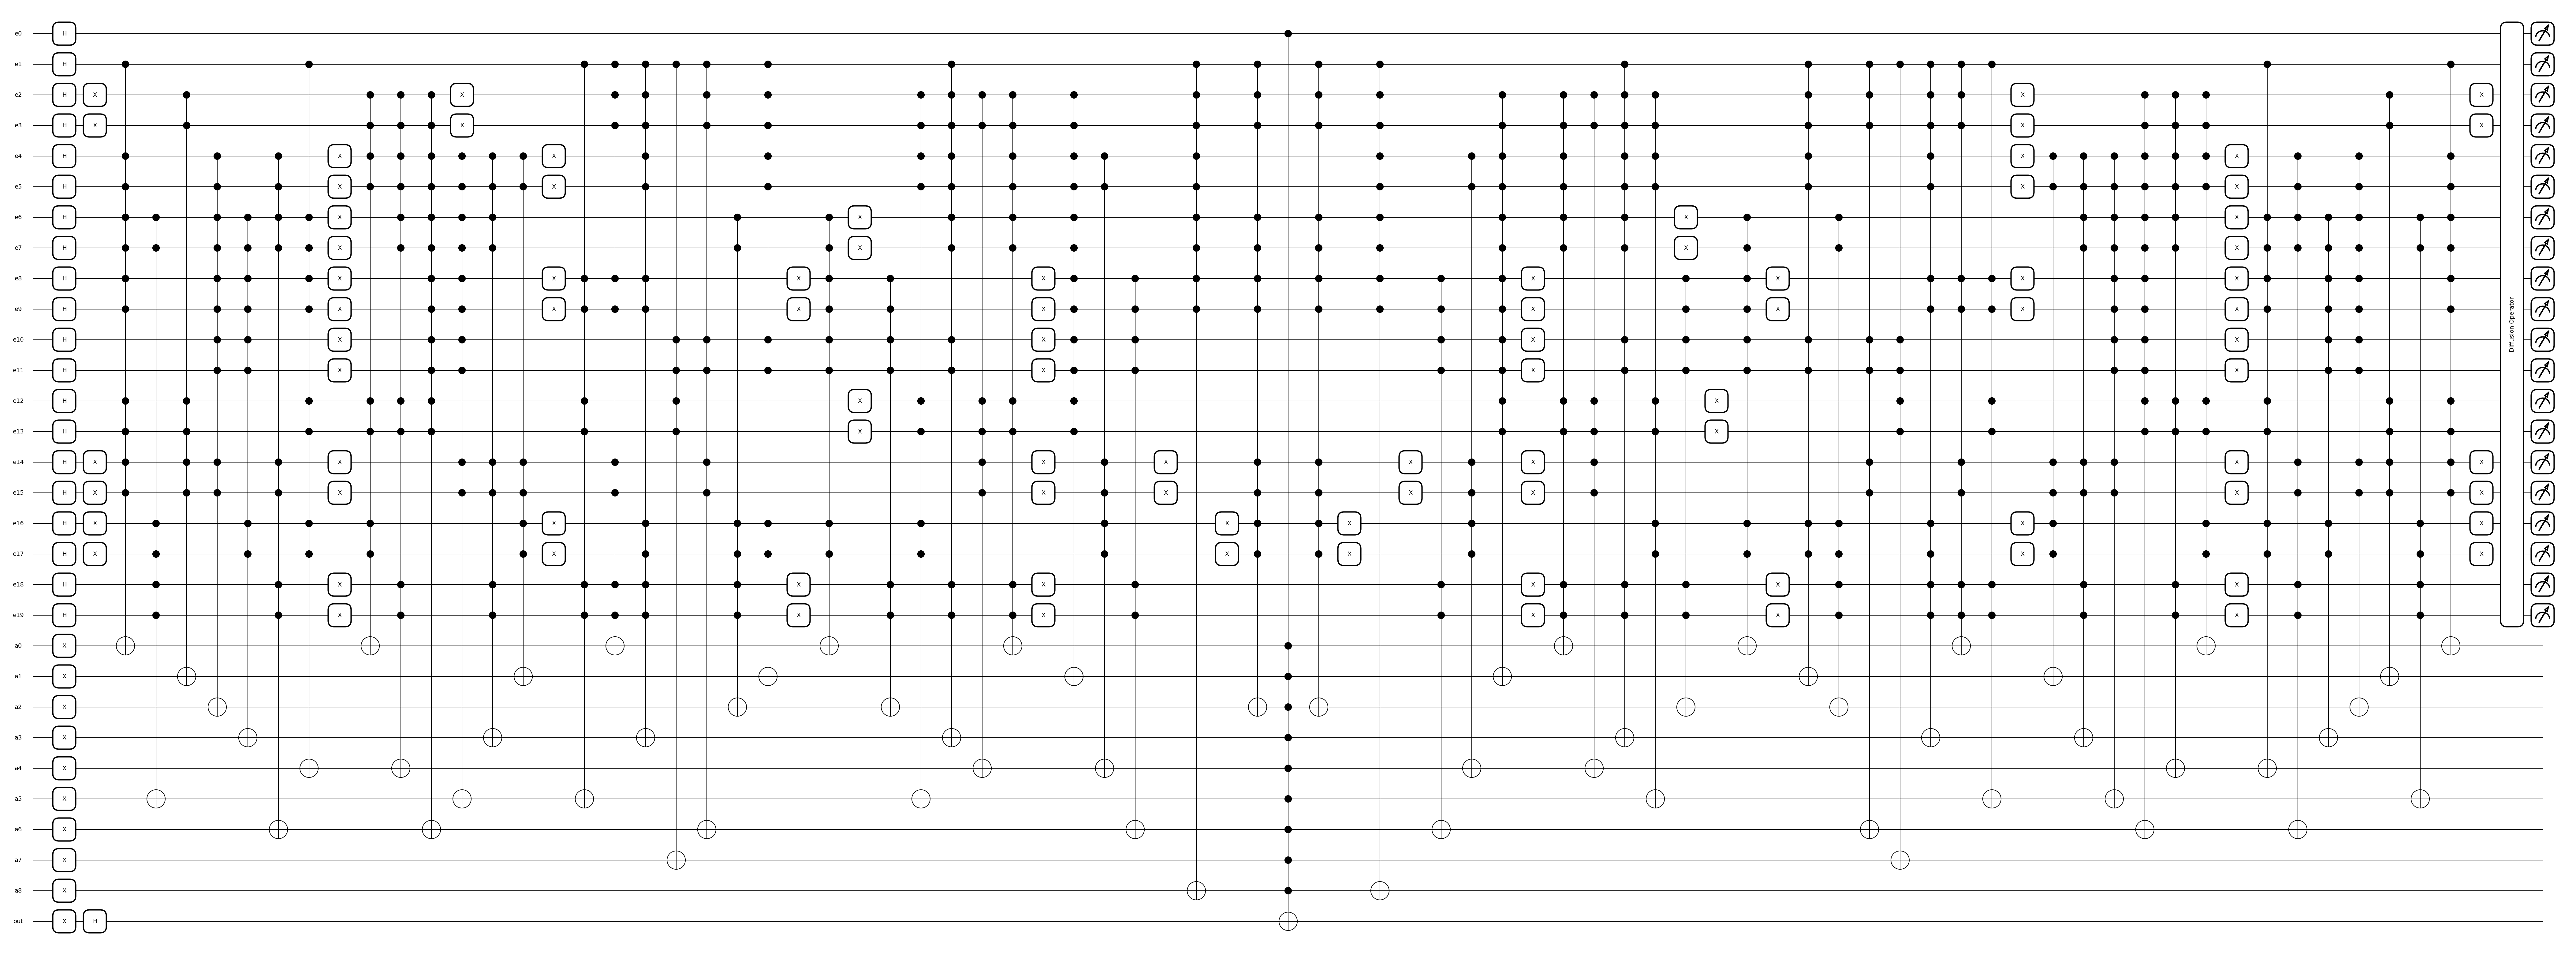

In [19]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [20]:
get_depth(circuit3)

The depth of the circuit is: 57


In [21]:
#num_casual_states(circuit3(), cut = 300)

# Optimization

## OPTUNA

In [22]:
import itertools
import optuna
import math

# List of original subsets
subconjuntos_base = depth_combination3[0]


# Precomputes the permutations of each subset (as a list of tuples)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputes the number of permutations of each subset
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total amount of permutations with a subset order fixed
total_comb_internas = math.prod(num_permutaciones)

# Amount of subset permutations
total_ordenes = math.factorial(len(subconjuntos_base))

# Total amount of possible permutations (not all permutations are generated)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodes internal indices for each subset
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Constructs the last combination
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Executes the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # Adjust the number of trials

# Shows the best value
best_idx = study.best_params["idx"]
best_combination = decodificar_combinacion(best_idx)
print("Best combination:", best_combination)
print("Minimum value:", study.best_value)


[I 2026-04-22 15:24:34,025] A new study created in memory with name: no-name-8dd5f335-8254-4164-bbb5-2185ea55c1f5
[I 2026-04-22 15:24:34,064] Trial 0 finished with value: 71.0 and parameters: {'idx': 212716907427617120}. Best is trial 0 with value: 71.0.
[I 2026-04-22 15:24:34,103] Trial 1 finished with value: 73.0 and parameters: {'idx': 264453863478246848}. Best is trial 0 with value: 71.0.
[I 2026-04-22 15:24:34,140] Trial 2 finished with value: 67.0 and parameters: {'idx': 529554722668821696}. Best is trial 2 with value: 67.0.
[I 2026-04-22 15:24:34,176] Trial 3 finished with value: 73.0 and parameters: {'idx': 196603148050992576}. Best is trial 2 with value: 67.0.
[I 2026-04-22 15:24:34,213] Trial 4 finished with value: 69.0 and parameters: {'idx': 176962628080204384}. Best is trial 2 with value: 67.0.
[I 2026-04-22 15:24:34,249] Trial 5 finished with value: 69.0 and parameters: {'idx': 134827806828214864}. Best is trial 2 with value: 67.0.
[I 2026-04-22 15:24:34,285] Trial 6 fini

Best combination: [[2, 4, 16], [18], [7, 3, 8, 21, 13, 17, 12], [20], [6, 15, 1, 11, 24], [27], [10, 5, 23, 14, 19, 0, 9], [22, 28, 29, 30, 25, 26]]
Minimum value: 61.0


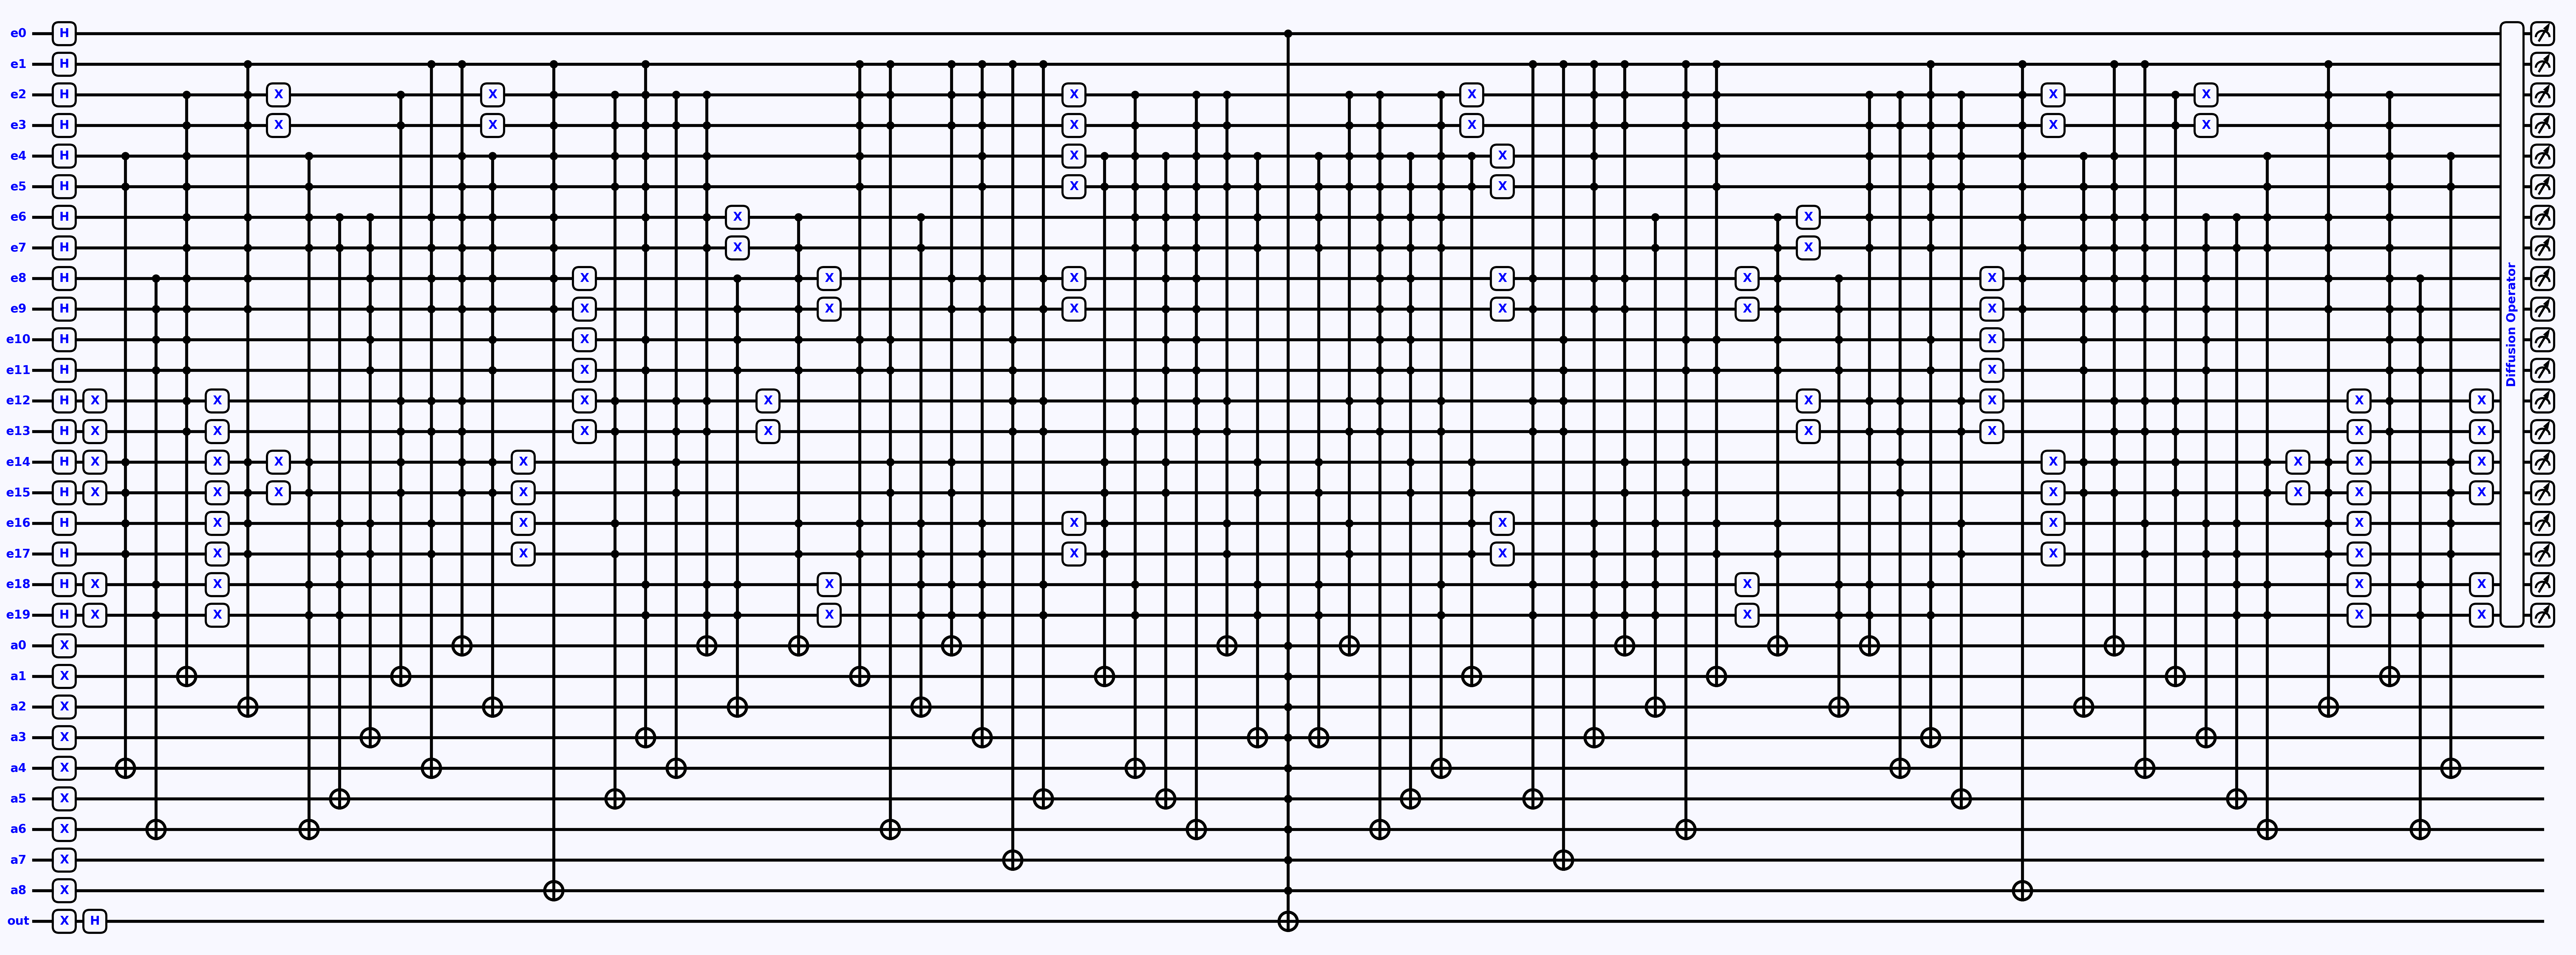

The depth of the circuit is: 61


In [23]:
circuit_D = circuit_function(best_combination)
Draw_circuit2(circuit_D, wire_order_list= total_wires, name_file = name_diagram)
get_depth(circuit_D)

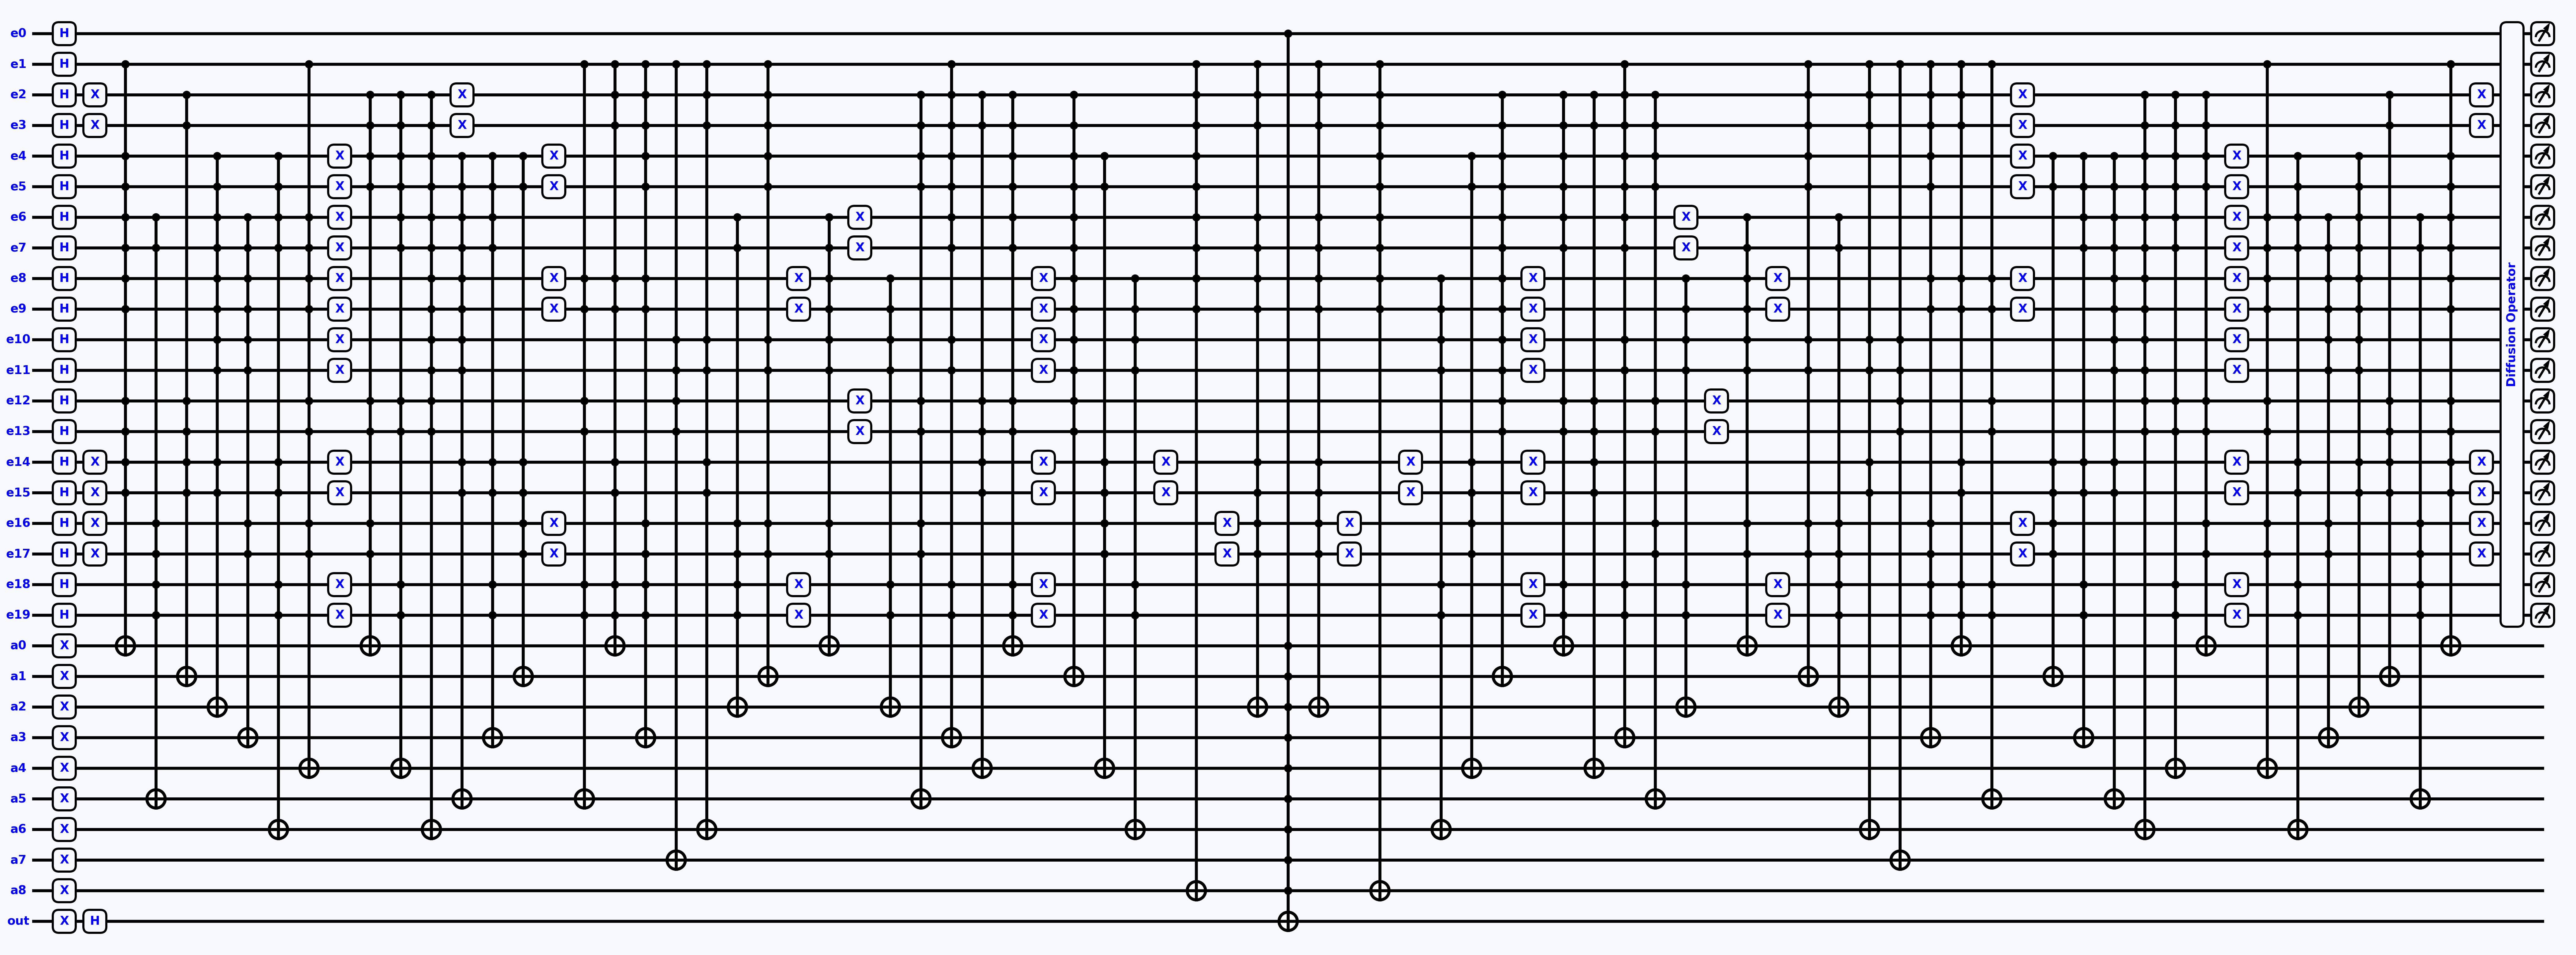

The depth of the circuit is: 57


In [24]:
test=[[17,3,21,12,8,7,13], [25,28,30,29,26,22], [9,14,19,0,5,23,10], [27], [24,6,15,1,11], [16,2,4], [20],[18]]
circuit_t = circuit_function(test)
Draw_circuit2(circuit_t, wire_order_list= total_wires, name_file = name_diagram)
get_depth(circuit_t)